In [1]:
import pandas as pd
import numpy as np

# --- 1. ЗАГРУЗКА ДАННЫХ ---
# Если файлы называются иначе, поменяй названия в кавычках
df_isk = pd.read_excel('iskovie.xlsx')
df_bik = pd.read_excel('bikmullin.xlsx')

# --- 2. ОЧИСТКА ФАЙЛА С ИСКОВЫМИ ТРЕБОВАНИЯМИ ---
# Берем только нужные колонки: номер вагона и дату прибытия
df_isk = df_isk[['Номер вагоно-цистерны', 'Дата прибытия на станцию назначения']]

# Удаляем пустые строки (ту самую грязь со съехавшими ячейками)
df_isk = df_isk.dropna(subset=['Номер вагоно-цистерны', 'Дата прибытия на станцию назначения'])

# Приводим номера вагонов к строковому типу и убираем лишние пробелы, чтобы они точно совпали
df_isk['Номер вагоно-цистерны'] = df_isk['Номер вагоно-цистерны'].astype(str).str.strip()

# Приводим даты к формату даты (ошибочные значения станут NaT - Not a Time)
df_isk['Дата прибытия на станцию назначения'] = pd.to_datetime(df_isk['Дата прибытия на станцию назначения'], errors='coerce')

# Убираем возможные дубликаты вагонов из исковых требований
df_isk = df_isk.drop_duplicates(subset=['Номер вагоно-цистерны'])


# --- 3. ОЧИСТКА ФАЙЛА БИКМУЛЛИНА ---
df_bik = df_bik[['Номер вагона', 'Вес', 'Дата вывоза']]
df_bik = df_bik.dropna(subset=['Номер вагона', 'Вес', 'Дата вывоза'])
df_bik['Номер вагона'] = df_bik['Номер вагона'].astype(str).str.strip()

# Чистим колонку "Вес" (убираем пробелы, меняем запятые на точки, если они есть, переводим в числа)
if df_bik['Вес'].dtype == object:
    df_bik['Вес'] = df_bik['Вес'].str.replace(' ', '', regex=True).str.replace(',', '.', regex=True).astype(float)

df_bik['Дата вывоза'] = pd.to_datetime(df_bik['Дата вывоза'], errors='coerce')


# --- 4. ОБЪЕДИНЕНИЕ ТАБЛИЦ (JOIN) ---
# Склеиваем таблицы по ключу (номер вагона)
merged_df = pd.merge(df_bik, df_isk, left_on='Номер вагона', right_on='Номер вагоно-цистерны', how='inner')

# Убираем строки, где даты сломались или отсутствуют
merged_df = merged_df.dropna(subset=['Дата прибытия на станцию назначения', 'Дата вывоза'])


# --- 5. ПОСТРОЕНИЕ ЕЖЕДНЕВНОГО БАЛАНСА ---
# Определяем первую дату прибытия и последнюю дату вывоза для нашего календаря
min_date = merged_df['Дата прибытия на станцию назначения'].min()
max_date = merged_df['Дата вывоза'].max()

# Создаем список всех дней в этом диапазоне
date_range = pd.date_range(start=min_date, end=max_date)

daily_balances = []

# Проходимся по каждому дню календаря
for current_date in date_range:
    # ЛОГИКА: Газ считается "невывезенным" в конкретный день, если:
    # 1. Вагон уже прибыл (дата прибытия <= текущего дня)
    # 2. Газ ЕЩЕ НЕ вывезли (дата вывоза > текущего дня)
    mask = (merged_df['Дата прибытия на станцию назначения'] <= current_date) & (merged_df['Дата вывоза'] > current_date)

    # Суммируем вес всех вагонов, попавших под условие
    daily_weight = merged_df[mask]['Вес'].sum()

    daily_balances.append({
        'Дата': current_date,
        'Невывезенный объем (тонны)': round(daily_weight, 2)
    })

# Превращаем результат в красивую таблицу
result_df = pd.DataFrame(daily_balances)

# --- 6. ВЫВОД И СОХРАНЕНИЕ ---
print("Данные успешно рассчитаны! Вот первые 10 строк:")
print(result_df.head(10))

# Сохраняем в CSV файл, который можно будет скачать или загрузить в Supabase
result_df.to_csv('daily_gas_balance.csv', index=False)

Данные успешно рассчитаны! Вот первые 10 строк:
        Дата  Невывезенный объем (тонны)
0 2024-01-28                       38.65
1 2024-01-29                       38.65
2 2024-01-30                       38.65
3 2024-01-31                       38.65
4 2024-02-01                       38.65
5 2024-02-02                       38.65
6 2024-02-03                       38.65
7 2024-02-04                      155.15
8 2024-02-05                      116.50
9 2024-02-06                      116.50


--- Ключевые метрики ---
Максимальный объем невывезенного газа: 526.3 т. (зафиксирован 26.05.2024)
Средний ежедневный остаток: 228.6 т.
-------------------------


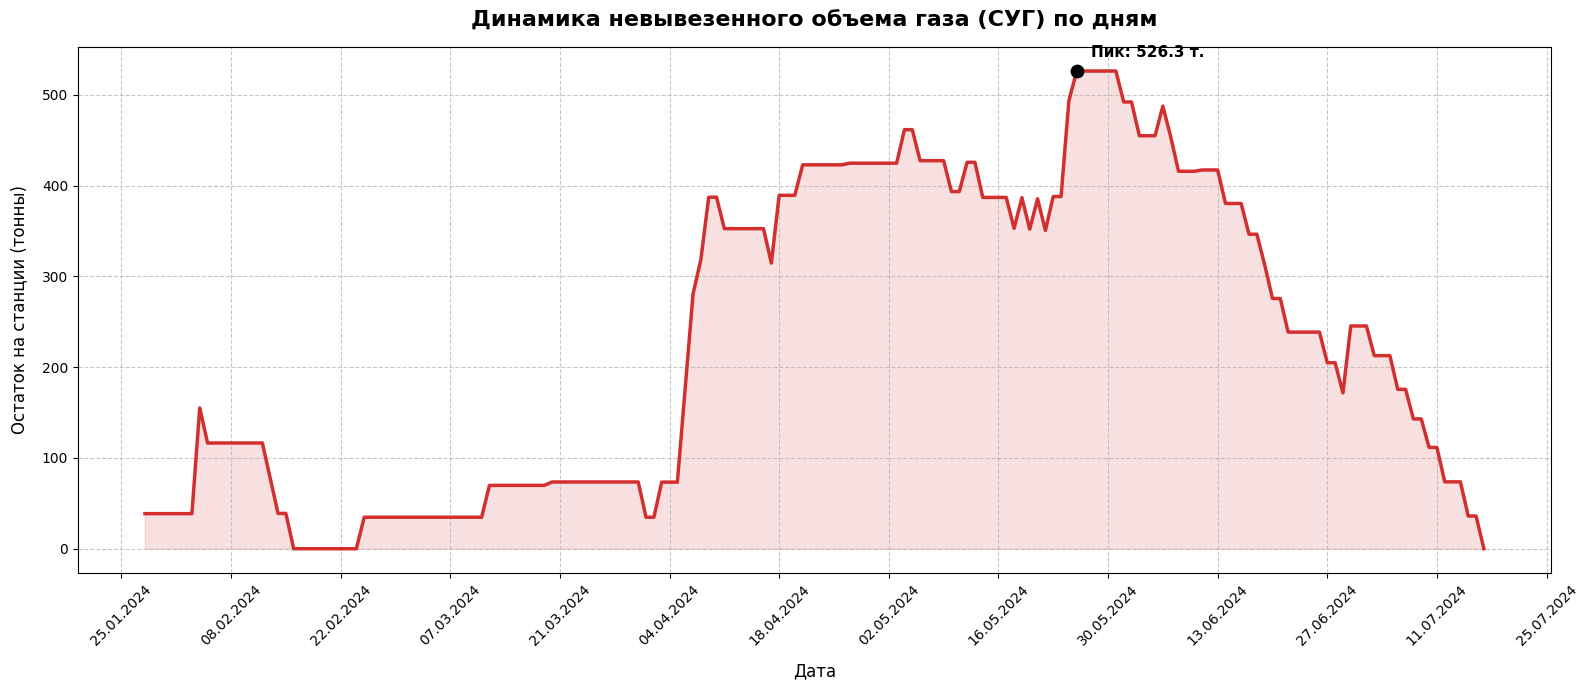

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Читаем сохраненный файл
df = pd.read_csv('daily_gas_balance.csv', parse_dates=['Дата'])

# 2. Считаем ключевые метрики
max_vol = df['Невывезенный объем (тонны)'].max()
mean_vol = df['Невывезенный объем (тонны)'].mean()
peak_date = df.loc[df['Невывезенный объем (тонны)'].idxmax(), 'Дата'].strftime('%d.%m.%Y')

print("--- Ключевые метрики ---")
print(f"Максимальный объем невывезенного газа: {max_vol} т. (зафиксирован {peak_date})")
print(f"Средний ежедневный остаток: {mean_vol:.1f} т.")
print("-" * 25)

# 3. Настройка внешнего вида графика
plt.figure(figsize=(16, 7))
plt.plot(df['Дата'], df['Невывезенный объем (тонны)'], color='#D32F2F', linewidth=2.5)

# Заливка области под графиком
plt.fill_between(df['Дата'], df['Невывезенный объем (тонны)'], color='#D32F2F', alpha=0.15)

# Оформление осей и заголовка
plt.title('Динамика невывезенного объема газа (СУГ) по дням', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=12, labelpad=10)
plt.ylabel('Остаток на станции (тонны)', fontsize=12, labelpad=10)

# Настройка сетки и дат на оси X (отметки каждые 2 недели)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14))
plt.xticks(rotation=45)

# Добавляем точку пика на график
plt.scatter(df.loc[df['Невывезенный объем (тонны)'].idxmax(), 'Дата'], max_vol, color='black', s=80, zorder=5)
plt.annotate(f'Пик: {max_vol} т.',
             xy=(df.loc[df['Невывезенный объем (тонны)'].idxmax(), 'Дата'], max_vol),
             xytext=(10, 10), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
# Задаем ставку штрафа (руб. за 1 тонну в день)
PENALTY_RATE = 30

# Считаем штраф за каждый день
df['Начислено за хранение (руб)'] = df['Невывезенный объем (тонны)'] * PENALTY_RATE

# Считаем общую сумму долга за весь период
total_penalty = df['Начислено за хранение (руб)'].sum()

print(f"Общая сумма начислений за хранение за весь период: {total_penalty:,.2f} руб.")

# Сохраняем итоговую витрину с финансами
df.to_csv('daily_gas_balance_with_penalties.csv', index=False)
print("Файл daily_gas_balance_with_penalties.csv успешно сохранен!")

# Выводим 10 дней с самыми большими начислениями
print("\nТоп-10 самых убыточных дней (по стоимости хранения):")
print(df.sort_values(by='Начислено за хранение (руб)', ascending=False).head(10))

Общая сумма начислений за хранение за весь период: 1,179,795.90 руб.
Файл daily_gas_balance_with_penalties.csv успешно сохранен!

Топ-10 самых убыточных дней (по стоимости хранения):
          Дата  Невывезенный объем (тонны)  Начислено за хранение (руб)
119 2024-05-26                      526.30                      15789.0
124 2024-05-31                      526.30                      15789.0
122 2024-05-29                      526.30                      15789.0
123 2024-05-30                      526.30                      15789.0
120 2024-05-27                      526.30                      15789.0
121 2024-05-28                      526.30                      15789.0
118 2024-05-25                      493.62                      14808.6
125 2024-06-01                      492.18                      14765.4
126 2024-06-02                      492.18                      14765.4
130 2024-06-06                      487.59                      14627.7


In [4]:
import pandas as pd
from google.colab import data_table

# Включаем красивые интерактивные таблицы в Colab
data_table.enable_dataframe_formatter()

# Загружаем наш итоговый файл с балансом и расчетом пеней
df_table = pd.read_csv('daily_gas_balance_with_penalties.csv', parse_dates=['Дата'])

# Оставляем дату только в формате YYYY-MM-DD для красоты отображения
df_table['Дата'] = df_table['Дата'].dt.strftime('%Y-%m-%d')

# Выводим таблицу
display(df_table)

,Дата,Невывезенный объем (тонны),Начислено за хранение (руб)
0,2024-01-28,38.65,1159.5
1,2024-01-29,38.65,1159.5
2,2024-01-30,38.65,1159.5
3,2024-01-31,38.65,1159.5
4,2024-02-01,38.65,1159.5
...,...,...,...
167,2024-07-13,73.70,2211.0
168,2024-07-14,73.70,2211.0
169,2024-07-15,36.05,1081.5
170,2024-07-16,36.05,1081.5


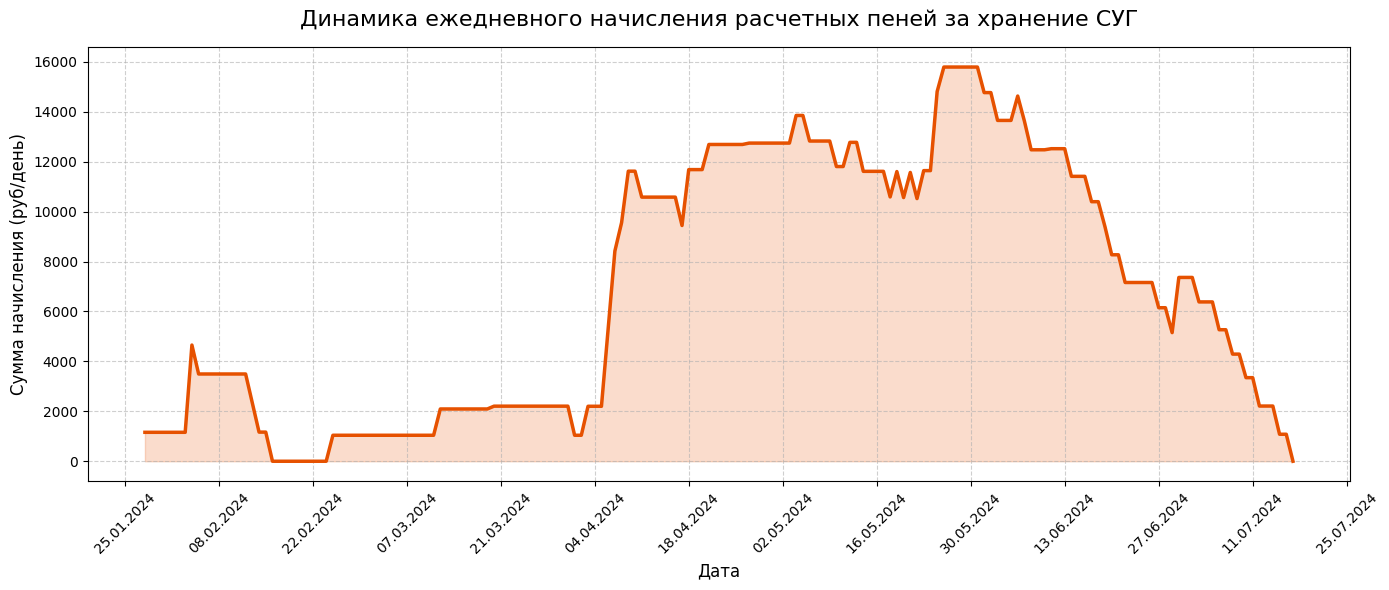

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Загружаем файл с рассчитанными пенями
df_penalties = pd.read_csv('daily_gas_balance_with_penalties.csv', parse_dates=['Дата'])

plt.figure(figsize=(14, 6))

# Строим график ежедневных начислений (оранжевая линия)
plt.plot(df_penalties['Дата'], df_penalties['Начислено за хранение (руб)'], color='#E65100', linewidth=2.5)
plt.fill_between(df_penalties['Дата'], df_penalties['Начислено за хранение (руб)'], color='#E65100', alpha=0.2)

# Оформление
plt.title('Динамика ежедневного начисления расчетных пеней за хранение СУГ', fontsize=16, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сумма начисления (руб/день)', fontsize=12)

# Настройка осей и сетки
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

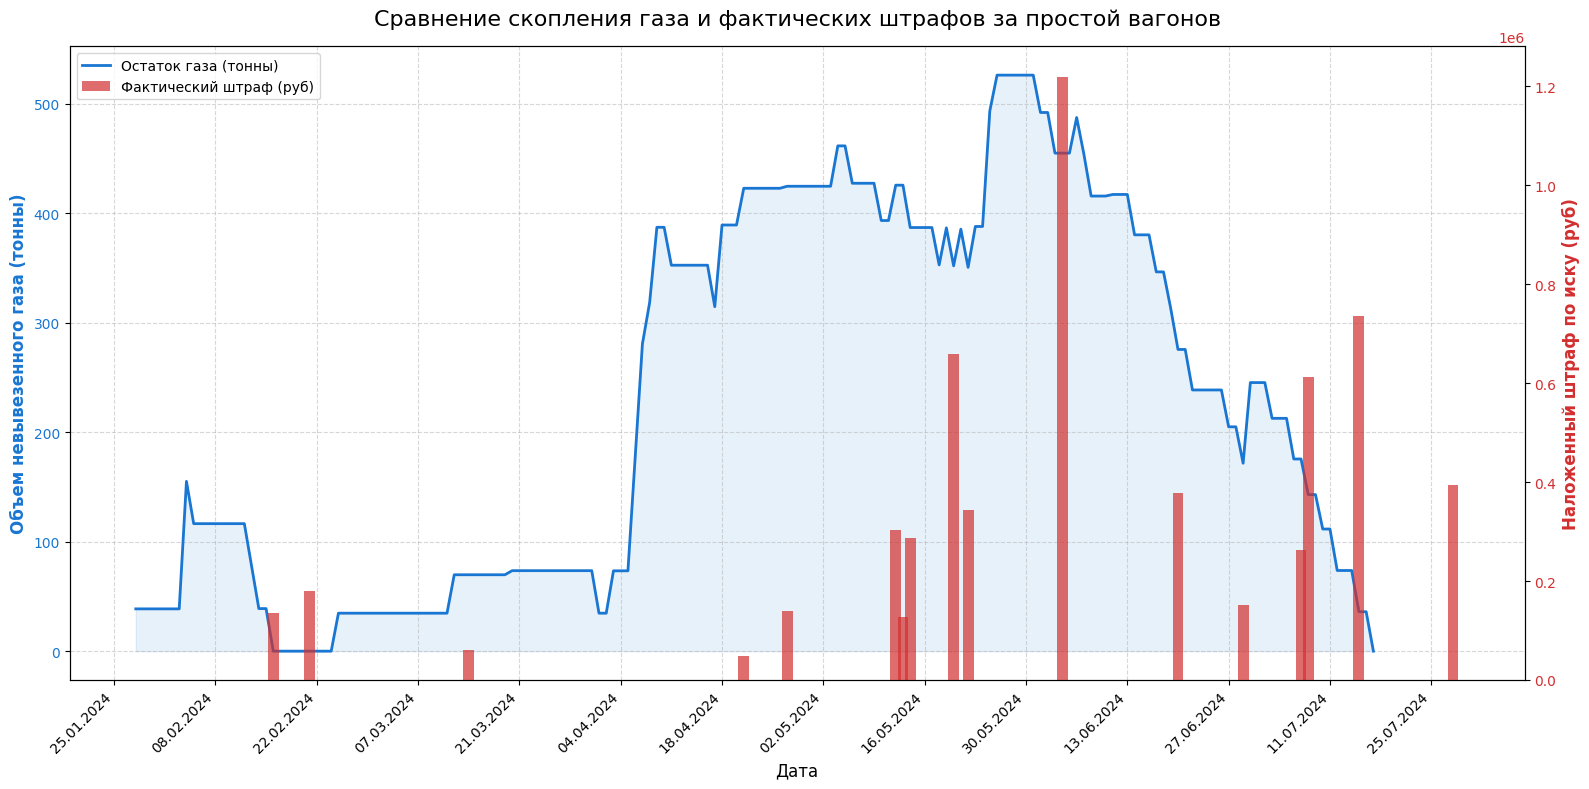

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. Подготовка данных об объеме газа ---
df_vol = pd.read_csv('daily_gas_balance.csv', parse_dates=['Дата'])

# --- 2. Подготовка данных о реальных штрафах из файла ---
df_isk = pd.read_excel('iskovie.xlsx')

# Вытаскиваем нужные колонки: дату отбытия порожней цистерны и сумму штрафа
df_isk['Дата отправления порожней цистерны'] = pd.to_datetime(df_isk['Дата отправления порожней цистерны'], errors='coerce')
# Очищаем суммы штрафов (убираем возможные пробелы и переводим в числа)
df_isk['Сумма штрафа'] = pd.to_numeric(df_isk['Сумма штрафа'].astype(str).str.replace(' ', ''), errors='coerce')

# Убираем строки с ошибками и группируем штрафы по датам фиксации
df_isk_clean = df_isk.dropna(subset=['Дата отправления порожней цистерны', 'Сумма штрафа'])
daily_actual_penalties = df_isk_clean.groupby('Дата отправления порожней цистерны')['Сумма штрафа'].sum().reset_index()
daily_actual_penalties.rename(columns={'Дата отправления порожней цистерны': 'Дата'}, inplace=True)

# --- 3. Построение совмещенного графика ---
fig, ax1 = plt.subplots(figsize=(16, 8))

# Ось 1 (Левая): Объем невывезенного газа
color_vol = '#1976D2'  # Синий
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Объем невывезенного газа (тонны)', color=color_vol, fontsize=12, fontweight='bold')
ax1.plot(df_vol['Дата'], df_vol['Невывезенный объем (тонны)'], color=color_vol, linewidth=2, label='Остаток газа (тонны)')
ax1.fill_between(df_vol['Дата'], df_vol['Невывезенный объем (тонны)'], color=color_vol, alpha=0.1)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.grid(True, linestyle='--', alpha=0.5)

# Ось 2 (Правая): Фактические штрафы (в виде столбцов)
ax2 = ax1.twinx()  # Создаем вторую ось Y
color_pen = '#D32F2F'  # Красный
ax2.set_ylabel('Наложенный штраф по иску (руб)', color=color_pen, fontsize=12, fontweight='bold')
# Рисуем столбцы, отображающие в какой день зафиксированы "убытки"
ax2.bar(daily_actual_penalties['Дата'], daily_actual_penalties['Сумма штрафа'], color=color_pen, alpha=0.7, width=1.5, label='Фактический штраф (руб)')
ax2.tick_params(axis='y', labelcolor=color_pen)

# Настройка оси дат
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=14))
fig.autofmt_xdate(rotation=45)

plt.title('Сравнение скопления газа и фактических штрафов за простой вагонов', fontsize=16, pad=15)

# Объединяем легенды для двух осей в одну
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()